In [2]:
# 1. Importowanie bibioltek i danych źródłowych
import pandas as pd
import numpy as np
df = pd.read_csv('National_Health_and_Aging_Trends_Study__NHATS____Vision_and_Eye_Health_Surveillance_System__VEHSS_.csv')

In [3]:
# 2. Przygotowanie danych do analizy

## Filtrowanie odpowiedzi dotyczących wrażliwości na kontrast
df_age = df[df["Question"] == "Contrast sensitivity"]

## Uwzglednienie tylko surowych danych, a nie przeliczonych do norm wiekowych
df_age = df_age[df_age["Data_Value_Type"] == "Crude Prevalence"]

## Usuwanie pustych wierszy
df_age = df_age.dropna(subset=["Data_Value", "Age", "Response"])

## Usuwanie "all ages" i wieku "65+"
df_age = df_age[df_age["Age"] != "All ages"]
df_age = df_age[df_age["Age"] != "65 years and older"]

# Wyeliminowanie duplikacji - filtrowanie odpowiedzi dla obu płci, wszystkich ras oraz nie uwzględnienia pozostałych czynników ryzyka
df_age = df_age[df_age["Sex"] == "Both sexes"]
df_age = df_age[df_age["RaceEthnicity"] == "All races"]
df_age = df_age[df_age["RiskFactor"] == "All participants"]

## porządkowanie wieku w odpowiedniej kolejności
age_order = ["65-69 years", "70-74 years", "75-79 years", "80-84 years", "85-89 years", "90 years and older"]
df_age["Age"] = pd.Categorical(df_age["Age"], categories=age_order, ordered=True)


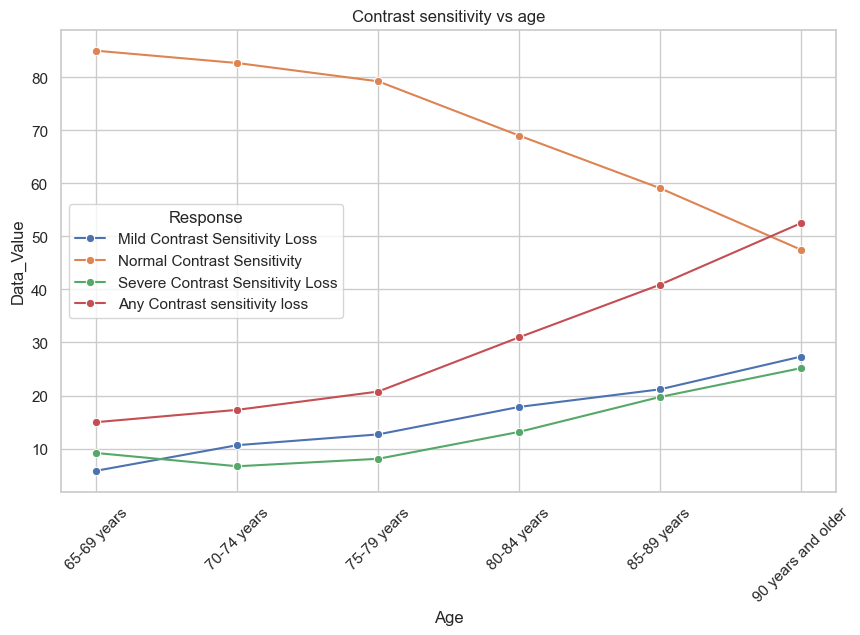

In [ ]:
# 3. Rozkład kategorii wrażliwości na kontrast według wieku
# wykres liniowy roboczy
## Importowanie bibliotek
import seaborn as sns
import matplotlib.pyplot as plt

## Przygotowanie wykresu
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_age,
    x="Age",
    y="Data_Value",
    hue="Response",
    marker="o"
)

plt.title("Contrast sensitivity vs age")
plt.xticks(rotation=45)
plt.show()



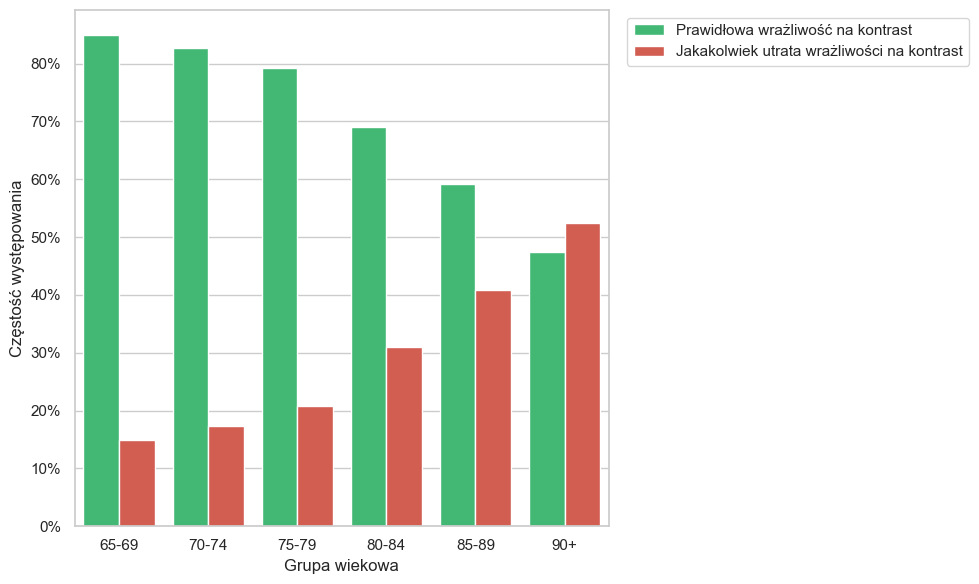

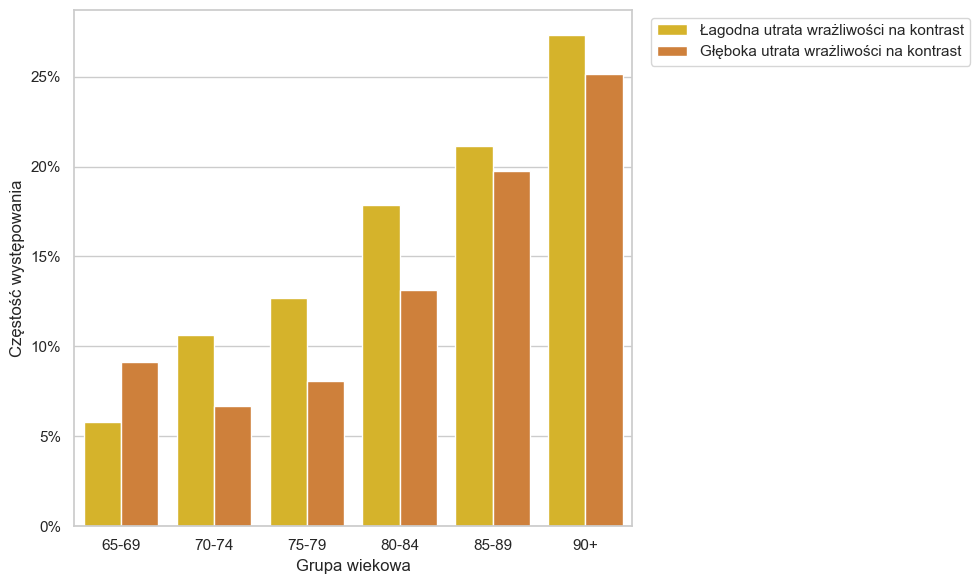

In [ ]:
# 3. Rozkład kategorii wrażliwości na kontrast według wieku
# Tworzenie 2 wykresów słupkowych
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


# Ustawienie globalnego stylu i siatki
sns.set_theme(style="whitegrid")

# NOWE, SKRÓCONE ETYKIETY DLA OSI X
# Muszą być w dokładnie takiej samej kolejności, w jakiej są zdefiniowane w age_order
nowe_etykiety_wieku = ["65-69", "70-74", "75-79", "80-84", "85-89", "90+"]


#Wykres 1:
#Częstość występowania prawidłowej oraz obniżonej wrażliwości na kontrast w zależności od grupy wiekowej pacjentów.

# Filtrowanie po oryginalnych angielskich nazwach z bazy
kategorie_ang_1 = ["Normal Contrast Sensitivity", "Any Contrast sensitivity loss"]
df_graph1 = df_age[df_age["Response"].isin(kategorie_ang_1)]

# Definiowaniey kolorów
kolory_wykres_1 = {
    "Normal Contrast Sensitivity": "#2ecc71",  # Zielony
    "Any Contrast sensitivity loss": "#e74c3c",  # Czerwony
}

plt.figure(figsize=(10, 6))

ax1 = sns.barplot(
    data=df_graph1,
    x="Age",
    y="Data_Value",
    hue="Response",
    hue_order=kategorie_ang_1,  # Pilnuje kolejności słupków
    palette=kolory_wykres_1,
    errorbar=None,
)

# Formatowanie osi Y na procenty (%)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Opisy osi i czyste etykiety wieku na dole
plt.xlabel("Grupa wiekowa", fontsize=12)
plt.ylabel("Częstość występowania", fontsize=12)
plt.xticks(
    ticks=range(len(nowe_etykiety_wieku)),
    labels=nowe_etykiety_wieku,
    rotation=0,
    ha="center",
)  # rotation=0, bo krótkie napisy nie muszą być pod kątem

# Podmiana angielskich napisów na polskie w legendzie
polskie_etykiety_1 = [
    "Prawidłowa wrażliwość na kontrast",
    "Jakakolwiek utrata wrażliwości na kontrast",
]
ax1.legend(
    labels=polskie_etykiety_1,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


# Wykres 2: 
# #Porównanie częstości występowania łagodnej i głębokiej utraty wrażliwości na kontrast w poszczególnych grupach wiekowych.

# Filtrowanie po oryginalnych angielskich nazwach
kategorie_ang_2 = [
    "Mild Contrast Sensitivity Loss",
    "Severe Contrast Sensitivity Loss",
]
df_graph2 = df_age[df_age["Response"].isin(kategorie_ang_2)]

# Definiowanie kolorów kluczy
kolory_wykres_2 = {
    "Mild Contrast Sensitivity Loss": "#f1c40f",  # Żółty
    "Severe Contrast Sensitivity Loss": "#e67e22",  # Pomarańczowy
}

plt.figure(figsize=(10, 6))

ax2 = sns.barplot(
    data=df_graph2,
    x="Age",
    y="Data_Value",
    hue="Response",
    hue_order=kategorie_ang_2,  # Pilnuje kolejności słupków
    palette=kolory_wykres_2,
    errorbar=None,
)

# Formatowanie osi Y na procenty (%)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Opisy osi i czyste etykiety wieku na dole
plt.xlabel("Grupa wiekowa", fontsize=12)
plt.ylabel("Częstość występowania", fontsize=12)
plt.xticks(
    ticks=range(len(nowe_etykiety_wieku)),
    labels=nowe_etykiety_wieku,
    rotation=0,
    ha="center",
)

# Podmiana angielskich napisów na polskie w legendzie
polskie_etykiety_2 = [
    "Łagodna utrata wrażliwości na kontrast",
    "Głęboka utrata wrażliwości na kontrast",
]
ax2.legend(
    labels=polskie_etykiety_2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [ ]:
# 4. Test niezależności chi-kwadrat i współczynnik V Craméra

## Importowanie bibliotek
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

## Usunięcie odpowiedzi, które nie będą uwzględnione w analizie
exclude_responses = ['Mild Contrast Sensitivity Loss','Severe Contrast Sensitivity Loss']
df_filtered_age = df_age[
    (~df_age["Response"].isin(exclude_responses)) & 
    (df_age["NonWeightedSample"].notna())
].copy()

## Tworzenie tabeli kontyngencji (szacowanie liczebności)
### Wyznaczanie średniej wielkość grupy dla każdej kategorii wiekowej (zabezpieczenie przed duplikacją)
group_sizes = pd.crosstab(
    df_filtered_age["Age"], 
    df_filtered_age["Response"], 
    values = df_filtered_age["NonWeightedSample"], 
    aggfunc="mean"
).fillna(0)
### Wyznaczanie średnie wartości procentowe dla danej kategorii
percentages = pd.crosstab(
    df_filtered_age["Age"], 
    df_filtered_age["Response"], 
    values=df_filtered_age["Data_Value"], 
    aggfunc="mean"
).fillna(0)

### Ostateczna wersja tabeli kontyngencji (przeliczenie procentów na liczby osób)
contingency = (percentages * group_sizes) / 100
#print(age_contingency)

## Wykonanie testu niezależności Chi-kwadrat Pearsona
chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency)

## Obliczenie V Cramera
def calculate_cramers_v(chi2, table):
    n = table.values.sum() 
    r, k = table.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

v_cramera = calculate_cramers_v(chi2_stat, contingency)

## Prezentacja wyników
print("TABELA KONTYNGENCJI (Szacowane liczby osób):")
print(contingency.round(1))
print("-" * 50)
print(f"ANALIZA STATYSTYCZNA: Wrażliwość na kontrast vs Wiek")
print(f"Liczebność próby (N):    {contingency.values.sum():.0f}")
print(f"Statystyka Chi2:         {chi2_stat:.4f}")
print(f"Wartość p:               {p_value:.4e}")
print(f"Stopnie swobody:         {dof}")
print(f"Współczynnik V Craméra:  {v_cramera:.4f}")
      
# Interpretacja jakościowa wg klasyfikacji Jacoba Cohena
if p_value < 0.05:
    if v_cramera < 0.1:
        strength = "pomijalna"
    elif v_cramera < 0.3:
        strength = "słaba"
    elif v_cramera < 0.5:
        strength = "umiarkowana"
    else:
        strength = "silna"
    print(f"Wniosek: Zależność istotna statystycznie, siła związku: {strength}.")
else:
    print("Wniosek: Brak istotnych statystycznie podstaw do odrzucenia hipotezy o niezależności.")




TABELA KONTYNGENCJI (Szacowane liczby osób):
Response            Any Contrast sensitivity loss  Normal Contrast Sensitivity
Age                                                                           
65-69 years                                 102.9                        584.1
70-74 years                                 176.5                        843.5
75-79 years                                 287.0                       1096.0
80-84 years                                 351.6                        783.4
85-89 years                                 286.3                        413.7
90 years and older                          262.0                        237.0
--------------------------------------------------
ANALIZA STATYSTYCZNA: Wrażliwość na kontrast vs Wiek
Liczebność próby (N):    5424
Statystyka Chi2:         368.5426
Wartość p:               1.7786e-77
Stopnie swobody:         5
Współczynnik V Craméra:  0.2607
Wniosek: Zależność istotna statystycznie, siła związku: słab